# Introduction

In [1]:
# Import packages
import pandas as pd
from src import helper
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%load_ext autoreload
%autoreload 2

# Sanity Check: Fulton vs Suffolk `hhtype`

## Load Marginals

Fulton County, GA - 1300100 <br>
Suffolk County, MA - 2503302

In [2]:
# Fulton County, GA
# Run this block to get the 'total column needed for plotting'
# Get the tract_hh_pops -> from marginals[1]
tract_hhtype_1300100 = pd.read_csv("synthpop_data/acs_marginals/1300100/tract_hhtype.csv")
# Row sum of the first row (index 0)
tract_hhtype_1300100['total'] = tract_hhtype_1300100.drop('geoid', axis=1).sum(axis=1)
tract_hhtype_1300100.head(3)

,geoid,MC,NS,SM,NF,GQ,total
0,13039010100,881,166,249,24,0,1320
1,13039010302,830,439,523,137,0,1929
2,13039010403,1161,228,295,31,0,1715


In [3]:
#  Sulffok County, MA
tract_hhtype_2503302 = pd.read_csv("synthpop_data/acs_marginals/2503302/tract_hhtype.csv")
tract_hhtype_2503302['total'] = tract_hhtype_2503302.drop('geoid', axis=1).sum(axis=1)
tract_hhtype_2503302.head(3)

,geoid,MC,NS,SM,NF,GQ,total
0,25025010500,329,72,1076,282,828,2587
1,25025010600,578,204,1030,234,0,2046
2,25025010701,303,18,795,264,393,1773


## Load Synthetic Pop

In [4]:
# Fulton County, GA
# Read spatially assigned data
syn_indvs_spatial_1300100 = pd.read_csv("synthpop_output/1300100/syn_indvs_spatial_1300100.csv")
syn_hhs_spatial_1300100 = pd.read_csv("synthpop_output/1300100/syn_hhs_spatial_1300100.csv")

In [5]:
# Suffolk County, MA
syn_hhs_spatial_2503302 = pd.read_csv("synthpop_output/2503302 - Copy/syn_hhs_spatial_2503302-example.csv")
syn_indvs_spatial_2503302 = pd.read_csv("synthpop_output/2503302 - Copy/syn_indvs_spatial_2503302-example.csv")

C:\Users\nicho\AppData\Local\Temp\ipykernel_15260\92303843.py:2: DtypeWarning: Columns (0: nchil, 1: i_age, 2: i_sex, 3: race_, 4: i_eth, 5: i_inc, 6: emply, 7: edu_q) have mixed types. Specify dtype option on import or set low_memory=False.
  syn_hhs_spatial_2503302 = pd.read_csv("synthpop_output/2503302 - Copy/syn_hhs_spatial_2503302-example.csv")
C:\Users\nicho\AppData\Local\Temp\ipykernel_15260\92303843.py:3: DtypeWarning: Columns (0: nchil) have mixed types. Specify dtype option on import or set low_memory=False.
  syn_indvs_spatial_2503302 = pd.read_csv("synthpop_output/2503302 - Copy/syn_indvs_spatial_2503302-example.csv")


## Plot 1

'Difference in Proportion for Each `hhtype` Category'


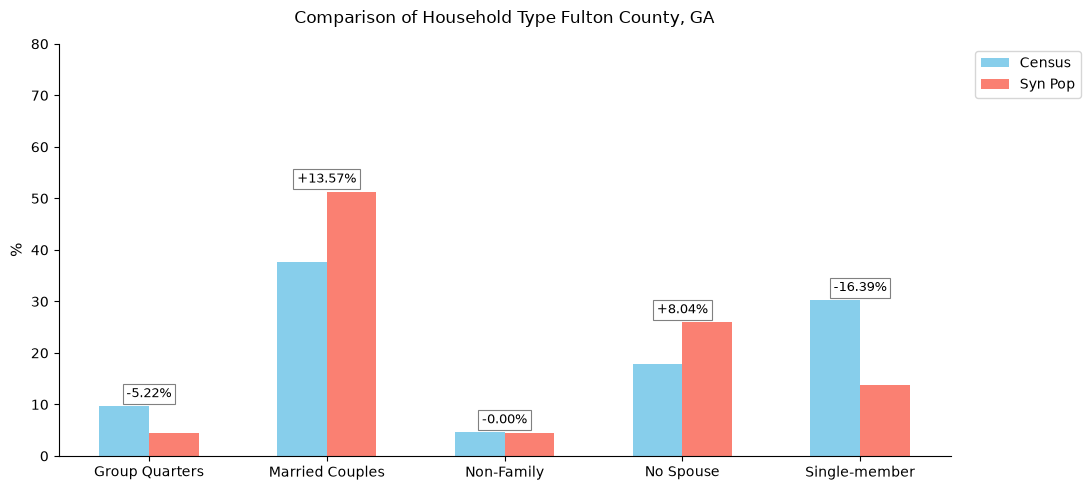

,hhtype,hhtype,census_pct,syn_pct,pct_diff
0,GQ,Group Quarters,9.626902,4.406246,-5.220656
1,MC,Married Couples,37.712322,51.286372,13.574050
2,NF,Non-Family,4.550810,4.547804,-0.003006
3,NS,No Spouse,17.874325,25.918436,8.044111
4,SM,Single-member,30.235641,13.841141,-16.394499


In [6]:
# Fulton County, GA
# 2. Plot distribution
helper.generate_side_by_side_plot(tract_hhtype_1300100, syn_indvs_spatial_1300100, 'Fulton County, GA')

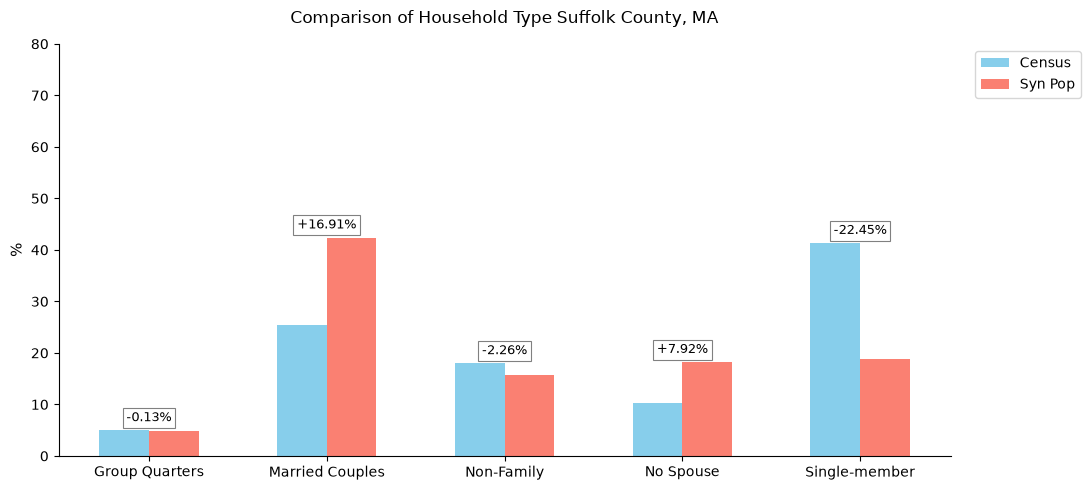

,hhtype,hhtype,census_pct,syn_pct,pct_diff
0,GQ,Group Quarters,4.961344,4.833705,-0.127639
1,MC,Married Couples,25.465177,42.378551,16.913374
2,NF,Non-Family,17.971565,15.715449,-2.256116
3,NS,No Spouse,10.286313,18.205050,7.918737
4,SM,Single-member,41.315600,18.867244,-22.448356


In [7]:
# Suffolk County, MA
helper.generate_side_by_side_plot(tract_hhtype_2503302, syn_indvs_spatial_2503302, 'Suffolk County, MA')

## Plot 2

In [9]:
# display(tract_hhtype_1300100.head(1))
# display(syn_indvs_spatial_1300100.head(1))
fulton_synpop_geoid_hhtype_df = syn_indvs_spatial_1300100.groupby(['geoid', 'hhtype']).agg('count').reset_index().rename(columns={'HHID':'count'})[['geoid', 'hhtype', 'count']]
fulton_synpop_geoid_hhtype_df['geoid_1'] = fulton_synpop_geoid_hhtype_df['geoid'].apply(lambda x: int(str(x)[:-1]))
fulton_synpop_geoid_hhtype_df = fulton_synpop_geoid_hhtype_df.groupby(['geoid_1', 'hhtype']).agg('sum').reset_index().drop('geoid', axis=1)
# fulton_synpop_geoid_hhtype_df.pivot(index='geoid_1', columns='hhtype', values='count').fillna(0)
# Pivot long df to wide
synpop_hhtype_1300100_df = fulton_synpop_geoid_hhtype_df.rename(columns={'count': 'count_synpop'})
synpop_hhtype_1300100_df.head()
# fulton_synpop_geoid_hhtype_df = fulton_synpop_geoid_hhtype_df.pivot(index='geoid_1', columns='hhtype', values='count').fillna(0).reset_index().sort_values('geoid_1')
# fulton_synpop_geoid_hhtype_df.columns.name = None
# fulton_synpop_geoid_hhtype_df.head()

,geoid_1,hhtype,count_synpop
0,13039010100,MC,2318
1,13039010100,NF,48
2,13039010100,NS,599
3,13039010100,SM,250
4,13039010302,GQ,201


In [33]:
geoid_totals_syn = synpop_hhtype_1300100_df.groupby('geoid_1')['count_synpop'].transform('sum')
synpop_hhtype_1300100_df['perc_syn'] = (synpop_hhtype_1300100_df['count_synpop'] / geoid_totals_syn) * 100
synpop_hhtype_1300100_df.head(1)

,geoid_1,hhtype,count_synpop,perc_syn
0,13039010100,MC,2318,72.099533


In [36]:
marginal_hhtype_1300100_df = tract_hhtype_1300100.melt(
    id_vars=['geoid'],                               
    value_vars=['MC', 'NS', 'SM', 'NF', 'GQ'],       
    var_name='hhtype',                               
    value_name='count'                               
).rename(columns={'count': 'count_marginals'})
geoid_totals_marg = marginal_hhtype_1300100_df.groupby('geoid')['count_marginals'].transform('sum')
marginal_hhtype_1300100_df['perc_marg'] = (marginal_hhtype_1300100_df['count_marginals'] / geoid_totals_marg) * 100
marginal_hhtype_1300100_df.head(1)

,geoid,hhtype,count_marginals,perc_marg
0,13039010100,MC,881,66.742424


In [37]:
hhtype_compare_1300100_df = synpop_hhtype_1300100_df.merge(marginal_hhtype_1300100_df, left_on=['geoid_1', 'hhtype'], right_on=['geoid','hhtype'])
hhtype_columns_to_keep = ['geoid', 'hhtype', 'perc_syn', 'perc_marg']
hhtype_compare_1300100_df = hhtype_compare_1300100_df[hhtype_columns_to_keep]
# hhtype_compare_1300100_df['diff'] = hhtype_compare_1300100_df['count_synpop'] - hhtype_compare_1300100_df['count_marginals']
hhtype_compare_1300100_df['perc_diff'] = hhtype_compare_1300100_df['perc_syn'] - hhtype_compare_1300100_df['perc_marg']
hhtype_compare_1300100_df.iloc[5:10, :][['geoid', 'hhtype', 'perc_diff']]

,geoid,hhtype,perc_diff
5,13039010302,MC,-0.136719
6,13039010302,NS,-16.236897
7,13039010302,SM,16.719439
8,13039010403,MC,-0.324779
9,13039010403,NF,-0.169355


In [38]:
df_matrix = hhtype_compare_1300100_df.pivot(index='geoid', columns='hhtype', values='perc_diff')

# Fill any missing category combinations with 0 so the heatmap stays uniform
df_matrix = df_matrix.fillna(0)

df_clipped_ma = df_matrix.clip(lower=-100, upper=100)

# Create a boolean mask identifying where infinite values live
inf_mask = np.isinf(df_clipped_ma.values)

# Clean up data matrix limits by grabbing only real numeric bounds
clean_values = df_clipped_ma.values[~inf_mask]

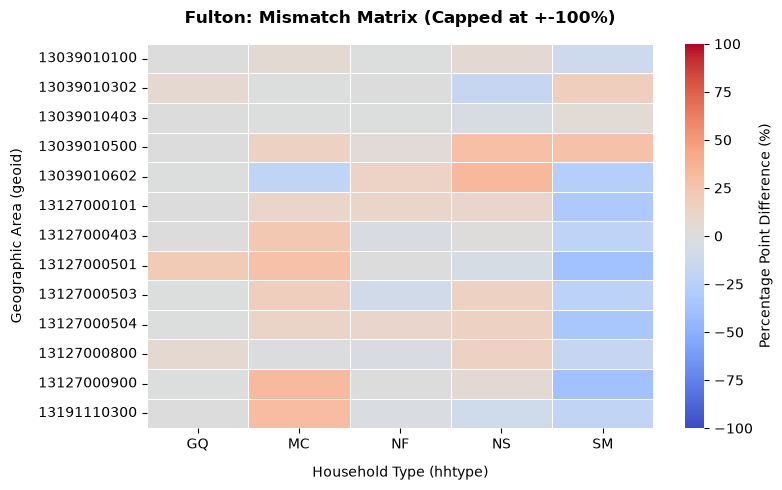

In [39]:
#=====================================================================
# 2. MASK THE INF VALUES FOR THE COLOR SCALE
# =====================================================================

vmax = max(abs(clean_values.min()), abs(clean_values.max()))
vmin = -vmax

# =====================================================================
# 3. GENERATE THE HEATMAP WITH BACKGROUND COLOR FILL
# =====================================================================
fig, ax = plt.subplots(figsize=(8, 5))

# Set the background facecolor of the axis. 
# Any masked (inf) cell will reveal this underlying color.
ax.set_facecolor('#d3d3d3') # Light slate grey (Change to any hex color you want)

sns.heatmap(
    df_clipped_ma, 
    fmt="",                  # Keeps mixed string handling clean
    cmap="coolwarm",         # Classic blue-to-red diverging palette
    center=0,                # Keeps perfect matches (0.0) neutral white
    vmin=-100,               # Hard limits the cool blue scale floor
    vmax=100,                # Hard limits the warm red scale ceiling
    linewidths=0.5,          
    cbar_kws={'label': 'Percentage Point Difference (%)'}
)

plt.title('Fulton: Mismatch Matrix (Capped at +-100%)', fontsize=12, pad=15, fontweight='bold')
plt.xlabel('Household Type (hhtype)', fontsize=10, labelpad=10)
plt.ylabel('Geographic Area (geoid)', fontsize=10, labelpad=10)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [16]:
# display(tract_hhtype_2503302.head(1))
# display(syn_indvs_spatial_2503302.head(1))
suffolk_synpop_geoid_hhtype_df = syn_indvs_spatial_2503302.groupby(['geoid', 'hhtype']).agg('count').reset_index().rename(columns={'HHID':'count'})[['geoid', 'hhtype', 'count']]
suffolk_synpop_geoid_hhtype_df['geoid_1'] = suffolk_synpop_geoid_hhtype_df['geoid'].apply(lambda x: int(str(x)[:-1]))
suffolk_synpop_geoid_hhtype_df = suffolk_synpop_geoid_hhtype_df.groupby(['geoid_1', 'hhtype']).agg('sum').reset_index().drop('geoid', axis=1)
# suffolk_synpop_geoid_hhtype_df.pivot(index='geoid_1', columns='hhtype', values='count').fillna(0)
# Pivot long df to wide
synpop_hhtype_2503302_df = suffolk_synpop_geoid_hhtype_df.rename(columns={'count': 'count_synpop'})
synpop_hhtype_2503302_df.head()
# suffolk_synpop_geoid_hhtype_df = suffolk_synpop_geoid_hhtype_df.pivot(index='geoid_1', columns='hhtype', values='count').fillna(0).reset_index().sort_values('geoid_1')
# suffolk_synpop_geoid_hhtype_df.columns.name = None
# suffolk_synpop_geoid_hhtype_df.head()

,geoid_1,hhtype,count_synpop
0,25025010500,GQ,519
1,25025010500,MC,750
2,25025010500,NF,1102
3,25025010500,NS,352
4,25025010500,SM,690


In [41]:
geoid_totals_syn_ma = synpop_hhtype_2503302_df.groupby('geoid_1')['count_synpop'].transform('sum')
synpop_hhtype_2503302_df['perc_syn'] = (synpop_hhtype_2503302_df['count_synpop'] / geoid_totals_syn_ma) * 100
synpop_hhtype_2503302_df.head(1)

,geoid_1,hhtype,count_synpop,perc_syn
0,25025010500,GQ,519,15.206563


In [42]:
marginal_hhtype_2503302_df = tract_hhtype_2503302.melt(
    id_vars=['geoid'],                                # Column to keep intact
    value_vars=['MC', 'NS', 'SM', 'NF', 'GQ'],       # Columns to turn into rows (excludes 'total')
    var_name='hhtype',                                # Name for the new category column
    value_name='count'                                # Name for the new numeric column
).rename(columns={'count': 'count_marginals'})
geoid_totals_marg_ma = marginal_hhtype_2503302_df.groupby('geoid')['count_marginals'].transform('sum')
marginal_hhtype_2503302_df['perc_marg'] = (marginal_hhtype_2503302_df['count_marginals'] / geoid_totals_marg_ma) * 100
marginal_hhtype_2503302_df[(marginal_hhtype_2503302_df['geoid'] == 25025010500) & 
                           (marginal_hhtype_2503302_df['hhtype'] == 'GQ')]

,geoid,hhtype,count_marginals,perc_marg
160,25025010500,GQ,828,32.006185


In [43]:
hhtype_compare_2503302_df = synpop_hhtype_2503302_df.merge(marginal_hhtype_2503302_df, left_on=['geoid_1', 'hhtype'], right_on=['geoid','hhtype'])
hhtype_columns_to_keep = ['geoid', 'hhtype', 'perc_syn', 'perc_marg']
hhtype_compare_2503302_df = hhtype_compare_2503302_df[hhtype_columns_to_keep]
# hhtype_compare_2503302_df['diff'] = hhtype_compare_2503302_df['count_synpop'] - hhtype_compare_2503302_df['count_marginals']
hhtype_compare_2503302_df['perc_diff'] = hhtype_compare_2503302_df['perc_syn'] - hhtype_compare_2503302_df['perc_marg']
hhtype_compare_2503302_df.iloc[5:10, :][['geoid', 'hhtype', 'perc_diff']]

,geoid,hhtype,perc_diff
5,25025010600,MC,11.383131
6,25025010600,NF,4.713492
7,25025010600,NS,-0.330978
8,25025010600,SM,-15.765646
9,25025010701,GQ,-7.790032


In [71]:
df_matrix_ma = hhtype_compare_2503302_df.pivot(index='geoid', columns='hhtype', values='perc_diff')

# Fill any missing category combinations with 0 so the heatmap stays uniform
df_matrix_ma = df_matrix_ma.fillna(0)

min_ma = round(df_matrix_ma.reset_index().iloc[:, 1:].min().min(), 0)
max_ma = round(df_matrix_ma.reset_index().iloc[:, 1:].max().max(), 0)
print(min_ma, max_ma)
# df_clipped_ma = df_matrix_ma.clip(lower=-50, upper=50)

-40.0 40.0


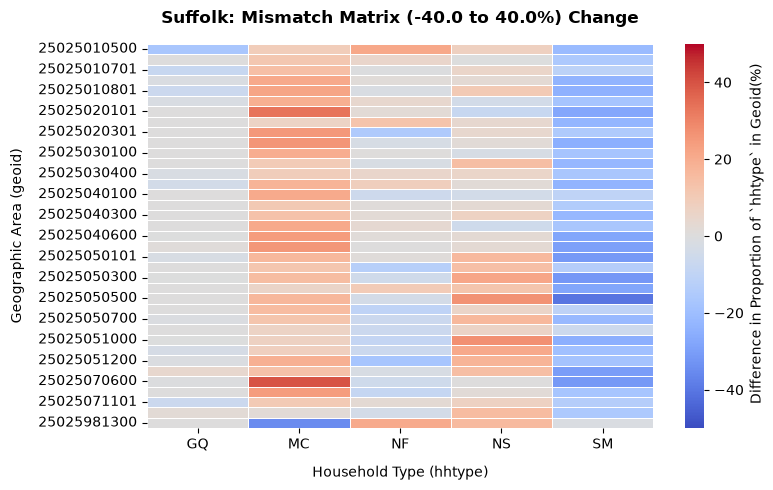

In [ ]:
#=====================================================================
# 2. MASK THE INF VALUES FOR THE COLOR SCALE
# =====================================================================

vmax = max(abs(clean_values.min()), abs(clean_values.max()))
vmin = -vmax

# =====================================================================
# 3. GENERATE THE HEATMAP WITH BACKGROUND COLOR FILL
# =====================================================================
fig, ax = plt.subplots(figsize=(8, 5))

# Set the background facecolor of the axis. 
# Any masked (inf) cell will reveal this underlying color.
ax.set_facecolor('#d3d3d3') # Light slate grey (Change to any hex color you want)

sns.heatmap(
    df_matrix_ma, 
    fmt="",                  # Keeps mixed string handling clean
    cmap="coolwarm",         # Classic blue-to-red diverging palette
    center=0,                # Keeps perfect matches (0.0) neutral white
    vmin=-50,               # Hard limits the cool blue scale floor
    vmax=50,                # Hard limits the warm red scale ceiling
    linewidths=0.5,          
    cbar_kws={'label': ' Difference in Proportion of `hhtype` in geoid (%)'}
)

plt.title(f'Suffolk: Mismatch Matrix ({min_ma} to {max_ma}%) Change', fontsize=12, pad=15, fontweight='bold')
plt.xlabel('Household Type (hhtype)', fontsize=10, labelpad=10)
plt.ylabel('Geographic Area (geoid)', fontsize=10, labelpad=10)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Pickle Files